<a href="https://colab.research.google.com/github/yeske12345/saasconversions/blob/main/retentionanalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# New Section

In [6]:
from google.colab import files
uploaded = files.upload()


Saving customer_retention_data.csv to customer_retention_data.csv


In [7]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("customer_retention_data.csv")
df.head()


,customer_id,signup_date,plan_tier,monthly_revenue,churn_date,tenure_months
0,CUST-0120,2021-01-04,Professional,96.27,2024-11-03,46.0
1,CUST-0168,2021-01-06,Starter,32.29,2024-07-04,41.9
2,CUST-0230,2021-01-11,Business,252.60,2021-03-18,2.2
3,CUST-0294,2021-01-12,Business,244.95,2025-05-12,51.9
4,CUST-0156,2021-01-22,Starter,26.98,2025-06-30,53.2


In [8]:
df["signup_date"] = pd.to_datetime(df["signup_date"])
df["churn_date"] = pd.to_datetime(df["churn_date"])
df["signup_month"] = df["signup_date"].dt.to_period("M")
df["churn_month"] = df["churn_date"].dt.to_period("M")
df["is_churned"] = df["churn_date"].notna()


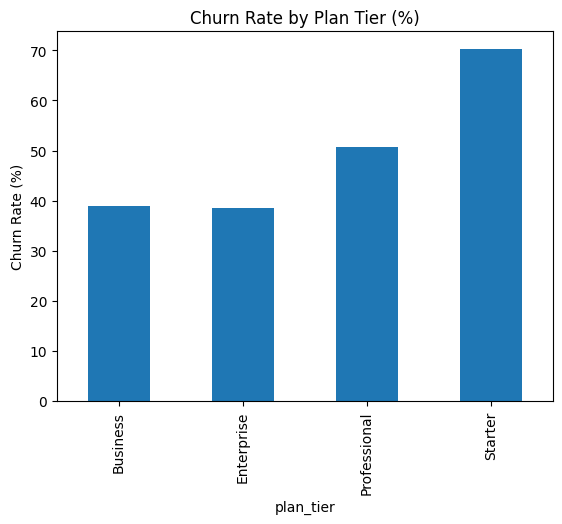

In [9]:
churn_by_plan = df.groupby("plan_tier")["is_churned"].mean() * 100
churn_by_plan.plot(kind="bar", title="Churn Rate by Plan Tier (%)")
plt.ylabel("Churn Rate (%)")
plt.show()

/tmp/ipykernel_1283/744622702.py:17: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


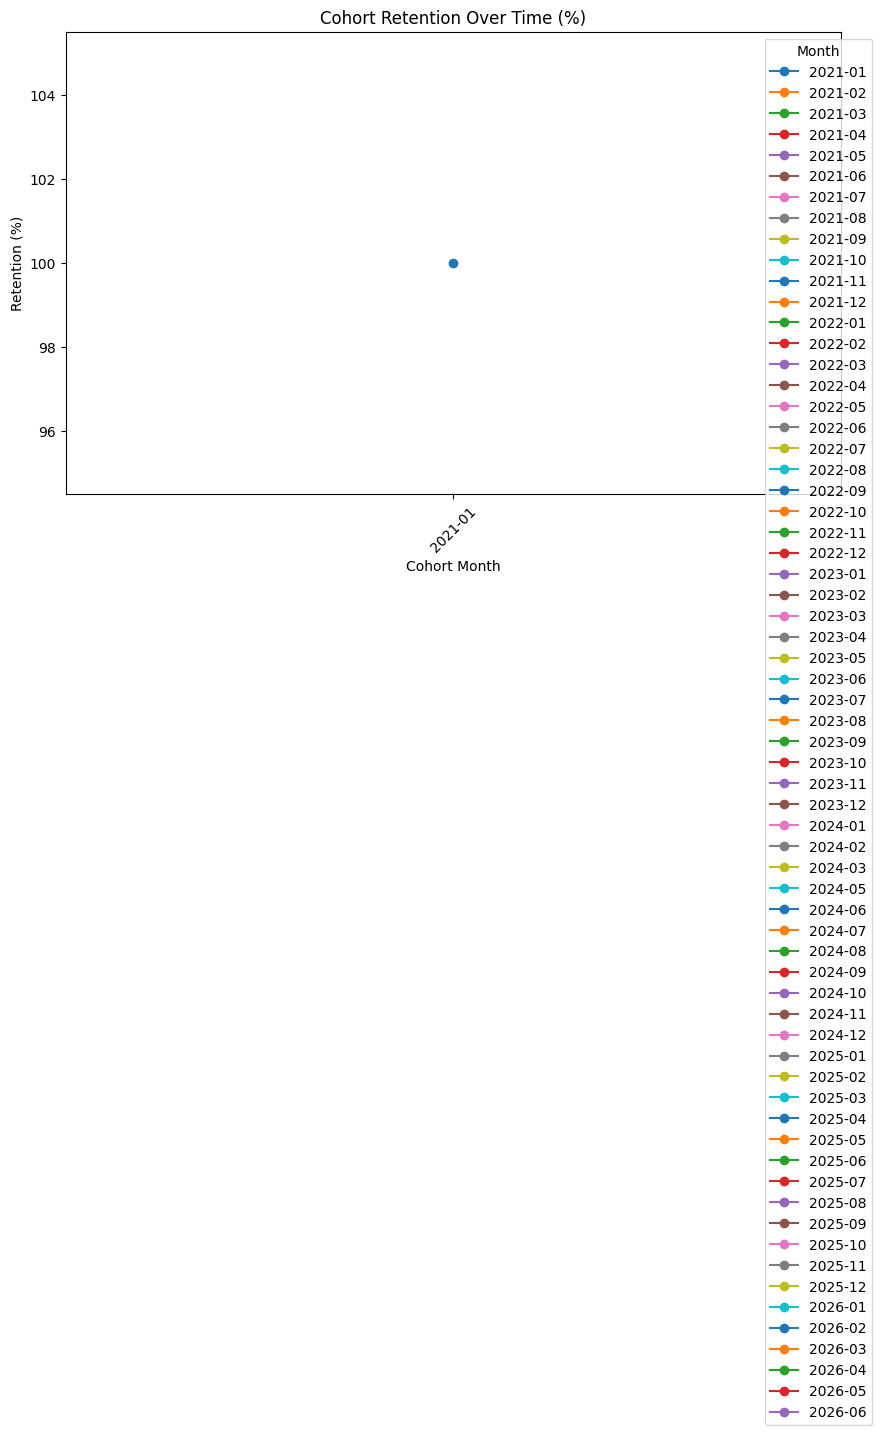

In [10]:
first_month = df.groupby("customer_id")["signup_month"].min().reset_index()
first_month.columns = ["customer_id", "cohort_month"]
df = df.merge(first_month, on="customer_id")

retention = df.groupby(["cohort_month", "signup_month"])["customer_id"].nunique().unstack()
retention_pct = retention.divide(retention.iloc[:, 0], axis=0) * 100
retention_pct = retention_pct.round(1)

plt.figure(figsize=(10, 6))
for col in retention_pct.columns:
    plt.plot(retention_pct.index.astype(str), retention_pct[col], marker="o", label=str(col))
plt.title("Cohort Retention Over Time (%)")
plt.xlabel("Cohort Month")
plt.ylabel("Retention (%)")
plt.xticks(rotation=45)
plt.legend(title="Month", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

In [11]:
print("Total Customers:", len(df))
print("Churned Customers:", df["is_churned"].sum())
print("Overall Churn Rate:", round(df["is_churned"].mean() * 100, 1), "%")
print("\nAverage Tenure (months):", round(df["tenure_months"].mean(), 1))
print("\nChurn Rate by Plan:")
print(churn_by_plan.round(1))

Total Customers: 300
Churned Customers: 175
Overall Churn Rate: 58.3 %

Average Tenure (months): 21.7

Churn Rate by Plan:
plan_tier
Business        38.9
Enterprise      38.5
Professional    50.7
Starter         70.3
Name: is_churned, dtype: float64
